In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import mysql.connector

In [2]:
mydb=mysql.connector.connect(host="localhost",user="root",password="gigaberosql",database="soccer")

In [3]:
pd.set_option("display.max_columns",100)
pd.options.mode.chained_assignment = None  # default='warn'

In [4]:
country=pd.read_sql("select * from country",mydb)
league=pd.read_sql("select * from league",mydb)
matches=pd.read_sql("select * from matches",mydb)
player=pd.read_sql("select * from player",mydb)
playerattributes=pd.read_sql("select * from player_attributes",mydb)
team=pd.read_sql("select * from team",mydb)
teamattributes=pd.read_sql("select * from team_attributes",mydb)

# create view of matches

In [5]:
merged=matches.merge(country,left_on="country_id",right_on="id")\
.merge(league,left_on="country_id",right_on="country_id")[["name_x","name_y","season","date","home_team_api_id","home_team_goal","away_team_goal","away_team_api_id"]]\
.merge(team,left_on="home_team_api_id",right_on="team_api_id")\
.merge(team,left_on="away_team_api_id",right_on="team_api_id")\
[["name_x","name_y","season","date","home_team_api_id","away_team_api_id","team_long_name_x","home_team_goal","away_team_goal","team_long_name_y"]]

merged.rename(columns={"name_x":"country","name_y":"league","team_long_name_x":"home_team","team_long_name_y":"away_team"},inplace=True)
merged["date"]=pd.to_datetime(merged.date).dt.date
viewmatches=merged[~merged.league.isin(["Portugal Liga ZON Sagres","Belgium Jupiler League","Poland Ekstraklasa","Scotland Premier League","Switzerland Super League"])]
#viewmatches
viewmatches["goals"]=viewmatches.home_team_goal+viewmatches.away_team_goal
viewmatches

,country,league,season,date,home_team_api_id,away_team_api_id,home_team,home_team_goal,away_team_goal,away_team,goals
1728,England,England Premier League,2008/2009,2008-08-17,10260,10261,Manchester United,1,1,Newcastle United,2
1729,England,England Premier League,2010/2011,2010-08-16,10260,10261,Manchester United,3,0,Newcastle United,3
1730,England,England Premier League,2011/2012,2011-11-26,10260,10261,Manchester United,1,1,Newcastle United,2
1731,England,England Premier League,2012/2013,2012-12-26,10260,10261,Manchester United,4,3,Newcastle United,7
1732,England,England Premier League,2013/2014,2013-12-07,10260,10261,Manchester United,0,1,Newcastle United,1
...,...,...,...,...,...,...,...,...,...,...,...
24552,Spain,Spain LIGA BBVA,2014/2015,2015-03-20,10268,10267,Elche CF,0,4,Valencia CF,4
24553,Spain,Spain LIGA BBVA,2014/2015,2014-12-20,8372,10267,SD Eibar,0,1,Valencia CF,1
24554,Spain,Spain LIGA BBVA,2015/2016,2015-12-13,8372,10267,SD Eibar,1,1,Valencia CF,2
24555,Spain,Spain LIGA BBVA,2014/2015,2015-02-21,7869,10267,Córdoba CF,1,2,Valencia CF,3


# find the leagues with the most scored goals in each season

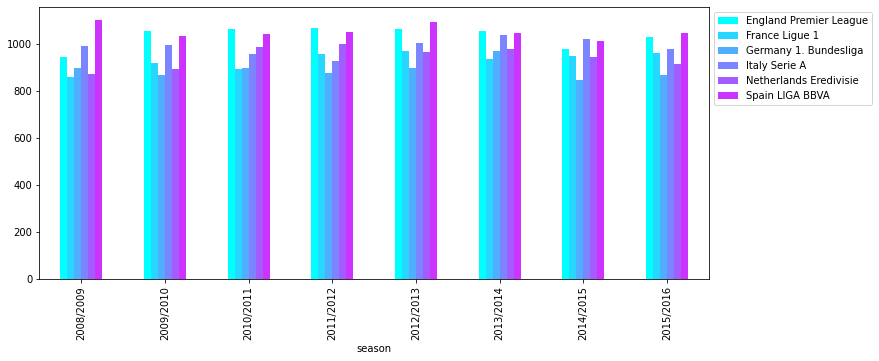

In [122]:
grouped=viewmatches.groupby(["season","league"])["goals"].sum().reset_index().sort_values(["season","league"])
pivoted=grouped.pivot("season","league","goals").reset_index()

pivoted.plot(kind="bar",x="season",figsize=(12,5),color=list(plt.get_cmap("cool")(np.linspace(0,0.8,6))),fontsize=10)
plt.legend(bbox_to_anchor=(1, 1),fontsize=10)
plt.show()

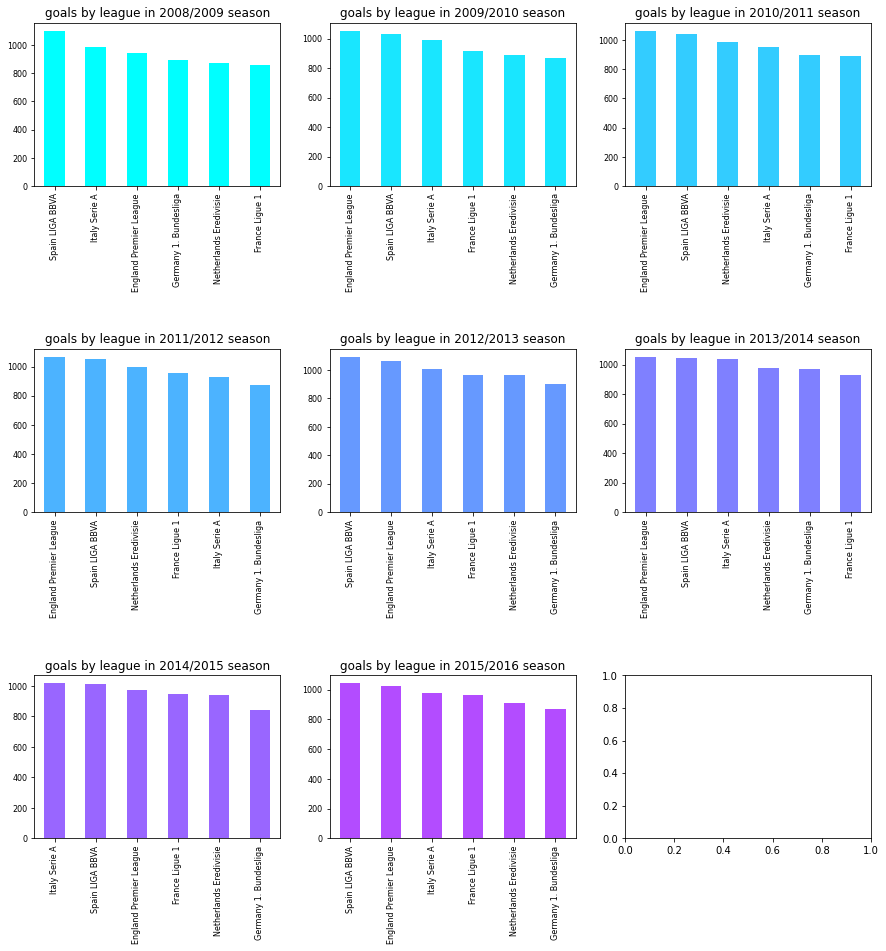

In [123]:
fig,axes=plt.subplots(3,3,figsize=(15,15))
cmap=plt.get_cmap("cool")
colors=list(cmap(np.linspace(0,0.7,len(viewmatches.season.unique()))))
for ax,s,c in zip(axes.ravel(),sorted(viewmatches.season.unique()),colors):
    filtered=viewmatches[viewmatches.season==s]
    filtered["goals"]=filtered.home_team_goal+filtered.away_team_goal
    grouped=filtered.groupby("league")["goals"].sum().reset_index().sort_values("goals",ascending=False)
    
    grouped.plot(kind="bar",x="league",y="goals",ax=ax,title="goals by league in "+s+" season",fontsize=8,xlabel="",color=c,legend=False)
    plt.subplots_adjust(hspace=1)
plt.show()

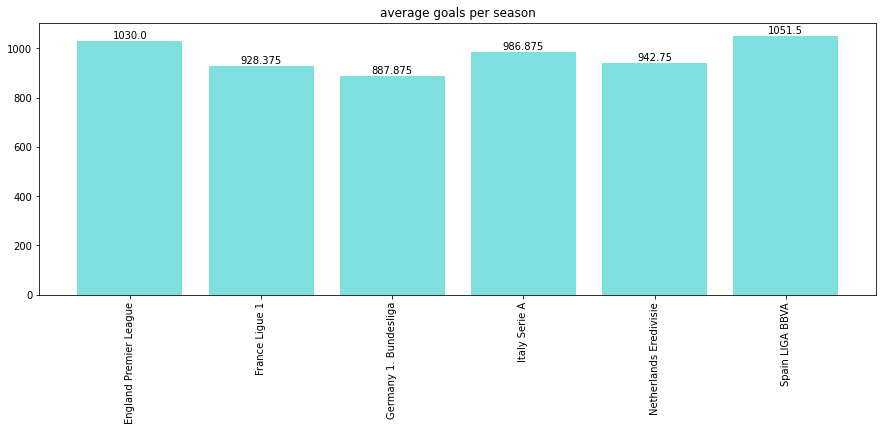

In [6]:
grouped=viewmatches.groupby(["season","league"])["goals"].sum().reset_index().sort_values(["season","league"])
grouped2=grouped.groupby("league")["goals"].mean().reset_index().sort_values("league")

plt.figure(figsize=(15,5))
plt.bar(grouped2.league,grouped2.goals,color="c",alpha=0.5)
plt.title("average goals per season")
plt.xticks(grouped2.league,rotation=90)
def value_label(x,y):
    for i in range(len(x)):
        plt.text(i,(y.iloc[i]),(y.iloc[i]),size=10,ha="center",va="bottom")
value_label(grouped2.league,grouped2.goals)
plt.show()

# goals distribution for every league 

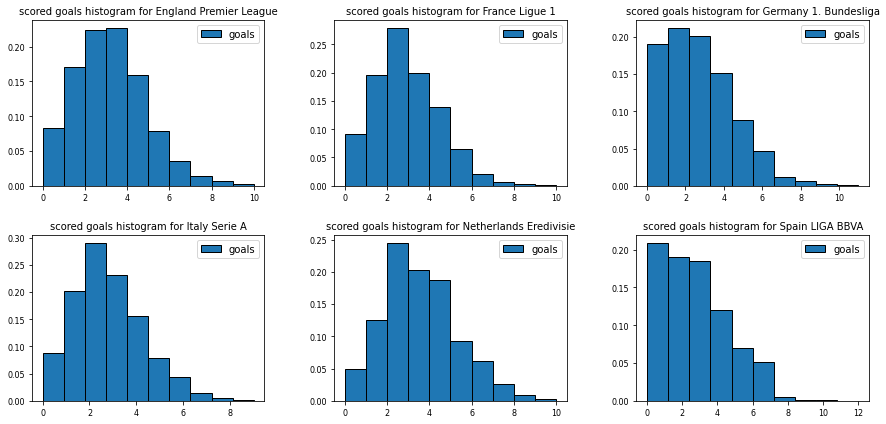

In [55]:
fig,axes=plt.subplots(2,3,figsize=(15,7))
for ax,l in zip(axes.ravel(),sorted(viewmatches.league.unique())):
    filtered=viewmatches[viewmatches.league==l]
    filtered.plot(kind="hist",ax=ax,y="goals",ec="k",density=True,fontsize=8)
    ax.set_title("scored goals histogram for "+l,size=10)
    ax.set_ylabel("")
    plt.subplots_adjust(hspace=0.3,wspace=0.3)
plt.show()

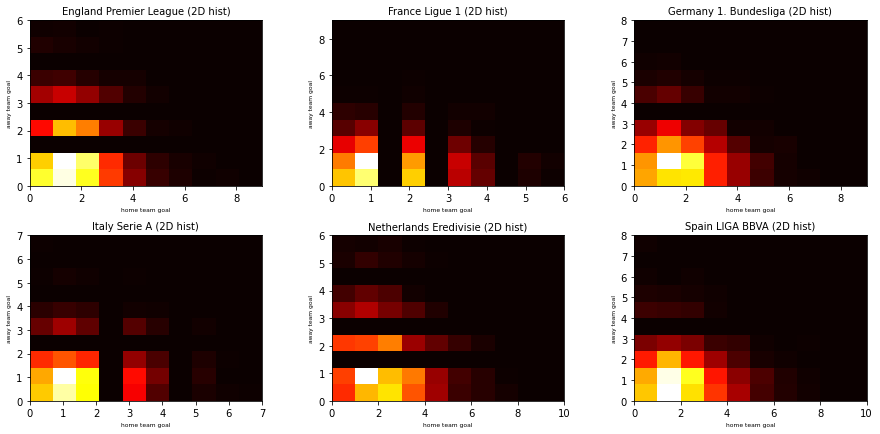

In [72]:
fig,axes=plt.subplots(2,3,figsize=(15,7))
for ax,l in zip(axes.ravel(),sorted(viewmatches.league.unique())):
    filtered=viewmatches[viewmatches.league==l]
    ax.hist2d(filtered.home_team_goal,filtered.away_team_goal,cmap="hot")
    ax.set_xlabel("home team goal",size=6)
    ax.set_ylabel("away team goal",size=6)
    ax.set_title(l+" (2D hist)",size=10)
    plt.subplots_adjust(hspace=0.3,wspace=0.3)
plt.show()

# plot avg goals per match for every league in each season

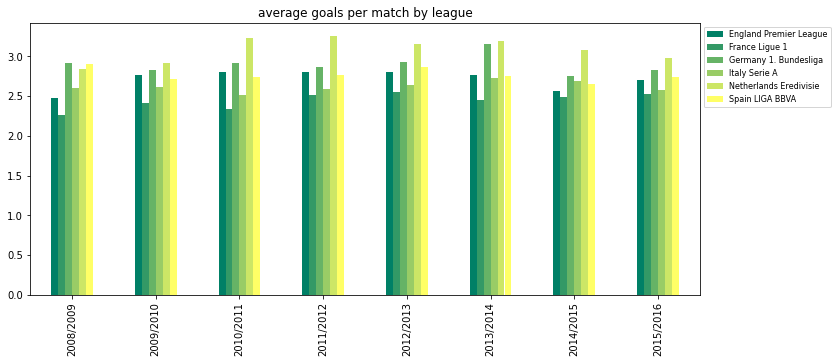

In [178]:
grouped=viewmatches.groupby(["season","league"])["goals"].mean().reset_index().sort_values(["season","goals"],ascending=[True,False]).groupby("season").head(6)
pivoted=grouped.pivot("season","league","goals").reset_index()
pivoted.plot(kind="bar",x="season",y=pivoted.columns[1:],figsize=(12,5),cmap="summer")
plt.title("average goals per match by league")
plt.legend(bbox_to_anchor=(1, 1),fontsize=8)
plt.xlabel(None)
plt.show()

# find teams which scored less goals than accepted in a season

In [26]:
h_grouped=viewmatches.groupby(["season","home_team"]).agg({"home_team_goal":"sum","away_team_goal":"sum"}).reset_index()
a_grouped=viewmatches.groupby(["season","away_team"]).agg({"home_team_goal":"sum","away_team_goal":"sum"}).reset_index()
merged=h_grouped.merge(a_grouped,left_on=["season","home_team"],right_on=["season","away_team"])\
[["season","home_team","home_team_goal_x","away_team_goal_x","home_team_goal_y","away_team_goal_y"]].sort_values(["season","home_team"])
merged.rename(columns={"home_team":"team"},inplace=True)

merged["scored"]=merged.home_team_goal_x+merged.away_team_goal_y
merged["accepted"]=merged.away_team_goal_x+merged.home_team_goal_y
merged[["season","team","scored","accepted"]]

,season,team,scored,accepted
0,2008/2009,1. FC Köln,35,50
1,2008/2009,ADO Den Haag,41,58
2,2008/2009,AJ Auxerre,35,35
3,2008/2009,AS Monaco,41,45
4,2008/2009,AS Nancy-Lorraine,38,47
...,...,...,...,...
923,2015/2016,Vitesse,55,38
924,2015/2016,Watford,40,50
925,2015/2016,West Bromwich Albion,34,48
926,2015/2016,West Ham United,65,51


# find  teams with the most goals scored in 2012/2013 season

In [36]:
filtered=viewmatches[viewmatches.season=="2012/2013"]
home_scored=filtered.groupby("home_team")["home_team_goal"].sum().reset_index()
away_scored=filtered.groupby("away_team")["away_team_goal"].sum().reset_index()
merged=home_scored.merge(away_scored,left_on="home_team",right_on="away_team")
merged.rename(columns={"home_team":"team"},inplace=True)
merged=merged[["team","home_team_goal","away_team_goal"]]
merged["scored"]=merged.home_team_goal+merged.away_team_goal
merged.sort_values("scored",ascending=False)

,team,home_team_goal,away_team_goal,scored
26,FC Barcelona,63,52,115
79,Real Madrid CF,67,36,103
65,PSV,58,45,103
27,FC Bayern Munich,56,42,98
52,Manchester United,45,41,86
...,...,...,...,...
96,Stade de Reims,20,13,33
94,Stade Brestois 29,17,15,32
70,Queens Park Rangers,13,17,30
69,Pescara,15,12,27


# for every season find top 5 teams with  the most average goals in a match

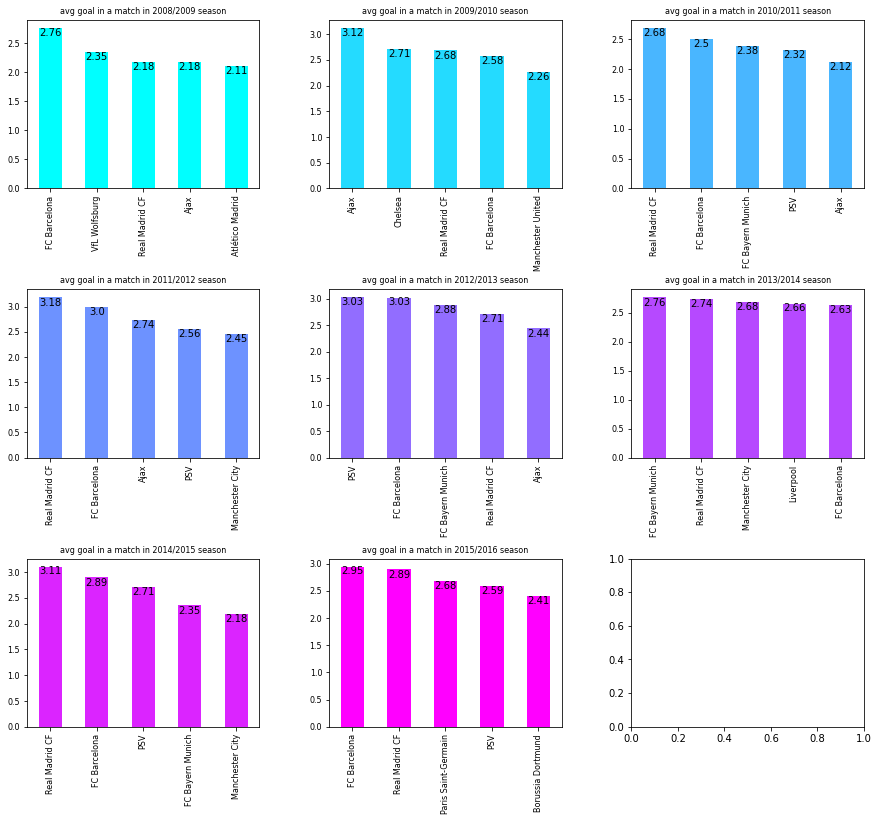

In [115]:
home_avg=viewmatches.groupby(["season","home_team"])["home_team_goal"].mean().reset_index()
away_avg=viewmatches.groupby(["season","away_team"])["away_team_goal"].mean().reset_index()
merged=home_avg.merge(away_avg,left_on=["season","home_team"],right_on=["season","away_team"])
merged.rename(columns={"home_team":"team"},inplace=True)
merged=merged[["season","team","home_team_goal","away_team_goal"]]
merged["avg_scored"]=(merged.home_team_goal+merged.away_team_goal)/2
merged=merged.sort_values(["season","avg_scored"],ascending=[True,False])
final=merged.groupby(["season"]).head(5)  # get top 5 result from every group(must be sorted in advance)


fig,axes=plt.subplots(3,3,figsize=(15,13))
cmap=plt.get_cmap("cool")
colors=list(cmap(np.linspace(0,1,len(final.season.unique()))))
for ax,s,c in zip(axes.ravel(),sorted(final.season.unique()),colors):
    filtered=final[final.season==s]
    filtered.plot(kind="bar",ax=ax,x="team",y="avg_scored",fontsize=8,xlabel="",legend=False,color=c)
    ax.set_title("avg goals in a match in "+s+" season",size=8)
    plt.subplots_adjust(hspace=0.6,wspace=0.3)
    def value_label(x,y):
        for i in range(len(x)):
            ax.text(i,round(y.iloc[i],2),round(y.iloc[i],2),size=10,ha="center",va="top")
    value_label(filtered.team,filtered.avg_scored)
plt.show()

# for every league find top 3 matchdays with the most scored goals

In [183]:
grouped=viewmatches.groupby(["league","date"]).apply(lambda x:(x["home_team_goal"]+x["away_team_goal"]).sum()).reset_index(name="goals").sort_values(["league","goals"],ascending=[True,False])
grouped.groupby("league").head(3)

,league,date,goals
266,England Premier League,2011-02-05,41
238,England Premier League,2010-11-27,36
513,England Premier League,2013-05-19,36
1131,France Ligue 1,2012-05-20,36
1469,France Ligue 1,2015-05-23,32
1048,France Ligue 1,2011-05-29,31
1960,Germany 1. Bundesliga,2012-05-05,35
2052,Germany 1. Bundesliga,2013-05-11,35
1678,Germany 1. Bundesliga,2009-05-23,34
2409,Italy Serie A,2009-05-31,42


# which club (and when) scored the most goals in an entire year?
# find most goal scoring team for each season 

In [54]:
h_grouped=viewmatches.groupby(["season","home_team"])["home_team_goal"].sum().reset_index()
a_grouped=viewmatches.groupby(["season","away_team"])["away_team_goal"].sum().reset_index()
merged=h_grouped.merge(a_grouped,left_on=["home_team","season"],right_on=["away_team","season"])
merged.rename(columns={"home_team":"team"},inplace=True)
merged["scored"]=merged.home_team_goal+merged.away_team_goal
merged.sort_values("scored",ascending=False)[["season","team","scored"]] # answer for question1

,season,team,scored
432,2011/2012,Real Madrid CF,121
777,2014/2015,Real Madrid CF,118
490,2012/2013,FC Barcelona,115
381,2011/2012,FC Barcelona,114
842,2015/2016,FC Barcelona,112
...,...,...,...
348,2011/2012,1. FC Kaiserslautern,24
26,2008/2009,De Graafschap,24
727,2014/2015,FC Dordrecht,24
717,2014/2015,Córdoba CF,22


In [46]:
merged.sort_values("scored",ascending=False).groupby("season").head(1).sort_values("season")  # answer for question2

,season,team,home_team_goal,away_team,away_team_goal,scored
29,2008/2009,FC Barcelona,61,FC Barcelona,44,105
125,2009/2010,Ajax,64,Ajax,42,106
315,2010/2011,Real Madrid CF,61,Real Madrid CF,41,102
432,2011/2012,Real Madrid CF,70,Real Madrid CF,51,121
490,2012/2013,FC Barcelona,63,FC Barcelona,52,115
662,2013/2014,Real Madrid CF,63,Real Madrid CF,41,104
777,2014/2015,Real Madrid CF,65,Real Madrid CF,53,118
842,2015/2016,FC Barcelona,67,FC Barcelona,45,112


# how many matches has bayern won against dortmund from 2008 to 2016?

In [8]:
home=viewmatches[(viewmatches.home_team=="FC Bayern Munich")&(viewmatches.away_team=="Borussia Dortmund")]
away=viewmatches[(viewmatches.away_team=="FC Bayern Munich")&(viewmatches.home_team=="Borussia Dortmund")]
home[home.home_team_goal>home.away_team_goal].shape[0]+away[away.home_team_goal<away.away_team_goal].shape[0]

7

# what was the biggest win?

In [51]:
unioned=pd.concat([home,away])
def balance(home_team,home_team_goal,away_team_goal):
    if home_team=="FC Bayern Munich":
        return home_team_goal-away_team_goal
    else:
        return away_team_goal-home_team_goal
unioned["balance"]=unioned.apply(lambda x:balance(x["home_team"],x["home_team_goal"],x["away_team_goal"]),axis=1)
x=unioned["balance"].max()
unioned[unioned["balance"].isin([x])]

,country,league,season,date,home_team_api_id,away_team_api_id,home_team,home_team_goal,away_team_goal,away_team,goals,balance
8121,Germany,Germany 1. Bundesliga,2015/2016,2015-10-04,9823,9789,FC Bayern Munich,5,1,Borussia Dortmund,6,4
10193,Germany,Germany 1. Bundesliga,2009/2010,2009-09-12,9789,9823,Borussia Dortmund,1,5,FC Bayern Munich,6,4


# for every championship find top 5 team which has won the most matches from 2008 to 2016

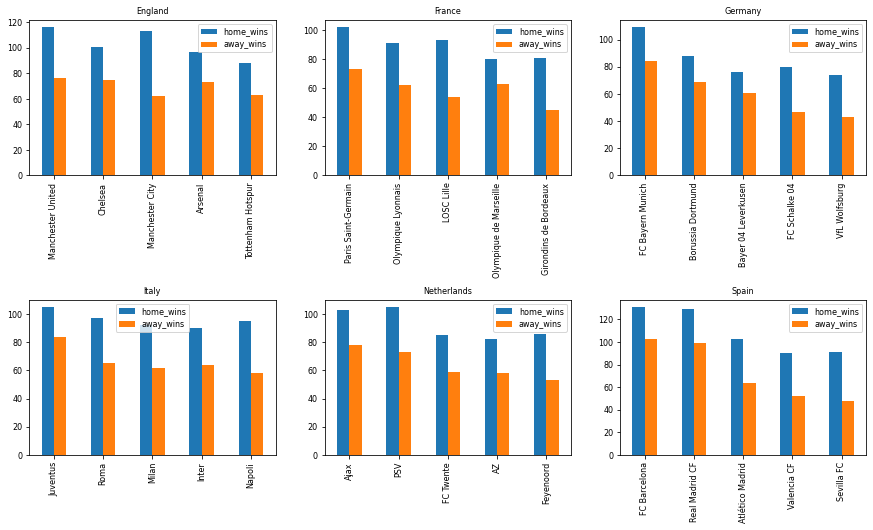

In [187]:
fig,axes=plt.subplots(2,3, figsize=(15,8))
for ax,country in zip(axes.ravel(),sorted(viewmatches.country.unique())):
    filtered=viewmatches[viewmatches.country==country]
    h_wins=filtered[filtered.home_team_goal>filtered.away_team_goal].groupby("home_team")["home_team"].count().reset_index(name="home_wins")
    a_wins=filtered[filtered.away_team_goal>filtered.home_team_goal].groupby("away_team")["away_team"].count().reset_index(name="away_wins")
    merged=h_wins.merge(a_wins,left_on="home_team",right_on="away_team")[["home_team","home_wins","away_wins"]]
    merged.rename(columns={"home_team":"team"},inplace=True)
    merged["wins"]=merged.home_wins+merged.away_wins
    merged=merged.sort_values("wins",ascending=False).head(5)


    merged.plot(kind="bar",ax=ax,x="team",y=["home_wins","away_wins"],fontsize=8)
    plt.subplots_adjust(hspace=0.8)
    ax.legend(fontsize=8)
    ax.set_title(country,fontsize=8)
    ax.set_xlabel("")
plt.show()

# find teams that has won more than 80% of matches in a season

In [70]:
hm=viewmatches.groupby(["season","home_team"])["home_team"].count().reset_index(name="home_matches")
hw=viewmatches[viewmatches.home_team_goal>viewmatches.away_team_goal].groupby(["season","home_team"])["home_team"].count().reset_index(name="home_wins")
home_final=hw.merge(hm, on=["season","home_team"])

am=viewmatches.groupby(["season","away_team"])["away_team"].count().reset_index(name="away_matches")
aw=viewmatches[viewmatches.away_team_goal>viewmatches.home_team_goal].groupby(["season","away_team"])["away_team"].count().reset_index(name="away_wins")
away_final=aw.merge(am, on=["season","away_team"])

merged=home_final.merge(away_final,left_on=["season","home_team"],right_on=["season","away_team"])

merged["wins"]=merged.home_wins+merged.away_wins
merged["matches"]=merged.home_matches+merged.away_matches
merged=merged[["season","home_team","wins","matches"]]
merged["win_percentage"]=(merged.wins/merged.matches*100).round(1)
merged[merged.win_percentage>80].sort_values(["season","win_percentage"],ascending=[True,False])



,season,home_team,wins,matches,win_percentage
147,2009/2010,FC Barcelona,31,38,81.6
195,2009/2010,Real Madrid CF,31,38,81.6
428,2011/2012,Real Madrid CF,32,38,84.2
487,2012/2013,FC Bayern Munich,29,34,85.3
486,2012/2013,FC Barcelona,32,38,84.2
628,2013/2014,Juventus,33,38,86.8
605,2013/2014,FC Bayern Munich,29,34,85.3
760,2014/2015,PSV,29,34,85.3
836,2015/2016,FC Bayern Munich,28,34,82.4
